In [2]:
# Enable automatic reloading of imported modules when their source changes
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from waxa import atomdata
from waxa.plotting import *

In [3]:
# ad = atomdata(62825,'andor_all')
ad = atomdata(0,'andor_all')

No ROI saved in run 64207.
ROI specified by string. Referencing roi.xslx spreadsheet (PotassiumData)...
ROI andor_all found.


In [126]:
print(ad.params.amp_imaging)

0.2


64207


Text(0.5, 1.0, 'Run 64207')

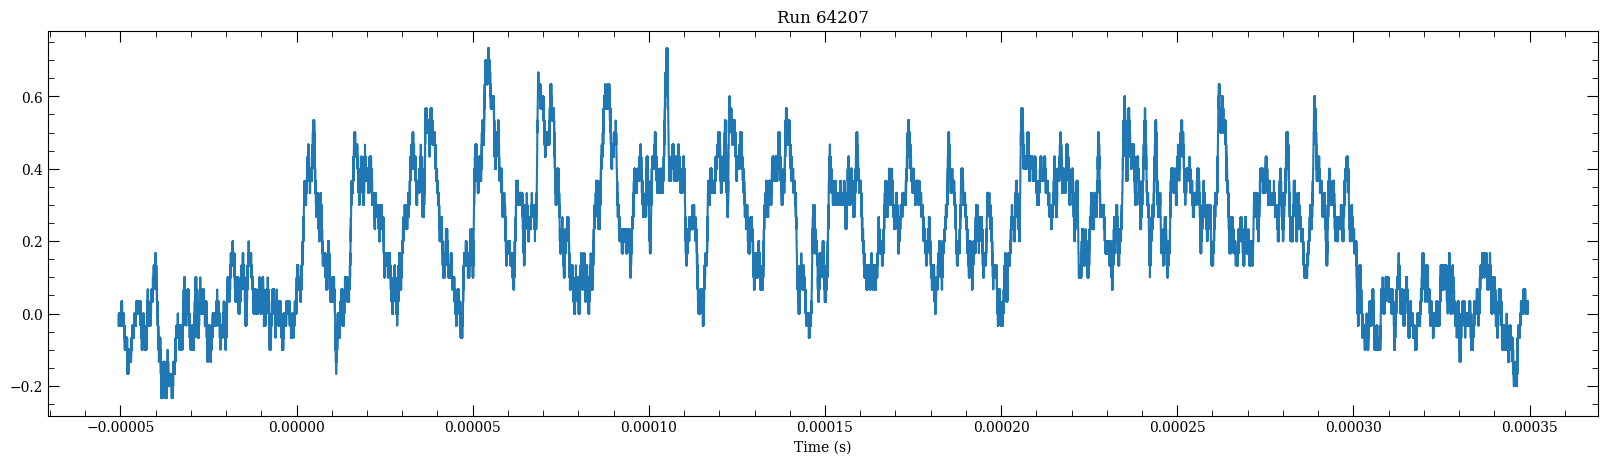

In [5]:
trace = ad.scope_data['PD'][0]

cuton = 0
cutoff = 800000

fig, axes = plt.subplots(1, figsize=[20,5])

print(ad.run_info.run_id)
idx = 2
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [6]:
print(np.std(trace.v[idx][cuton:cutoff]))

0.17911124


In [7]:
# Average repeats together into new array (works only for 1d xvar scan)

print(np.shape(trace.v)[0]/ad.params.N_repeats)

averaged_traces = np.zeros((int(np.shape(trace.v)[0]/ad.params.N_repeats),np.shape(trace.v)[1]))

for n in range(0,np.shape(trace.v)[0],ad.params.N_repeats):
    sum_trace = np.zeros((np.shape(trace.v)[1]))
    for t in range(ad.params.N_repeats):
        t = t + n
        sum_trace = trace.v[t] + sum_trace
    averaged_traces[int(n/ad.params.N_repeats)] = sum_trace / ad.params.N_repeats

10.0


64207


Text(0.5, 1.0, 'Run 64207')

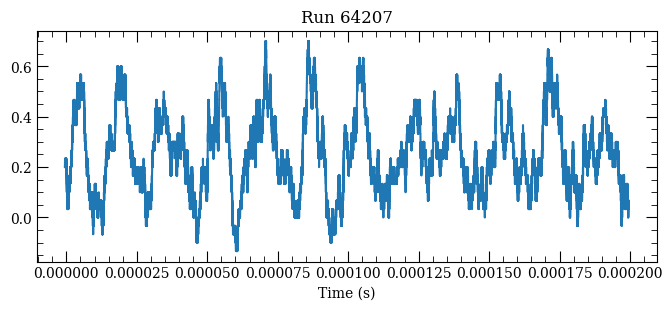

In [8]:
cuton = 100000
cutoff = 500000

fig, axes = plt.subplots(1, figsize=[8,3])

print(ad.run_info.run_id)
idx = 0
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
# axes.set_ylim(0.,4.5)
# axes.set_xlim(0.,30.e-6)
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_traces_grid(averaged_traces, x, labels=None, ncols=None, figsize=(12,8),
                     decimate=None, sharex=True, sharey=False, suptitle=None, xlabel=None,
                     ylim = None, xlim = None):
    """
    Plot each row of averaged_traces as a subplot in a grid.

    averaged_traces: (N, M) array where N=number of traces (20), M=points
    x: 1D x axis array with length M (e.g., trace.t[0])
    labels: list/array of length N with subplot labels (can be None)
    ncols: number of columns in grid (auto if None)
    figsize: figure size
    decimate: int or None — if int>1, plot every decimate-th sample to speed up
    sharex/sharey: whether to share axes
    suptitle: optional overall title
    """
    N = averaged_traces.shape[0]
    if labels is None:
        labels = [f"Trace {i}" for i in range(N)]
    if ncols is None:
        ncols = int(math.ceil(math.sqrt(N)))
    nrows = int(math.ceil(N / ncols))

    if decimate is not None and decimate > 1:
        x = x[::decimate]
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=sharex, sharey=sharey)
    axes = np.array(axes).reshape(-1)  # flatten to 1D for easy indexing

    for i in range(nrows * ncols):
        ax = axes[i]
        if i < N:
            trace = averaged_traces[i]
            if decimate is not None and decimate > 1:
                trace = trace[::decimate]
            ax.plot(x, trace, lw=0.8)
            ax.set_title(labels[i], fontsize=10)
            ax.grid(True, alpha=0.3)
            if ylim is not None:
                ax.set_ylim(ylim[0],ylim[1])
            if xlim is not None:
                ax.set_xlim(xlim[0],xlim[1])
        else:
            ax.axis('off')  # turn off unused subplots

    if suptitle:
        fig.suptitle(suptitle)
    # single x-label (prefer supxlabel when available)
    if xlabel is not None:
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel)
        else:
            fig.text(0.5, 0.02, xlabel, ha='center', fontsize=11)

    # leave room for labels/title
    fig.tight_layout(rect=[0.03, 0.01, 1, 0.99])
    plt.show()
    return fig, axes[:N]



xvar = amp_imaging, source = guess, detected unit = amp, multiplier = 1.0e+00
final xvarunit = amp, xvarmult = 1.0e+00


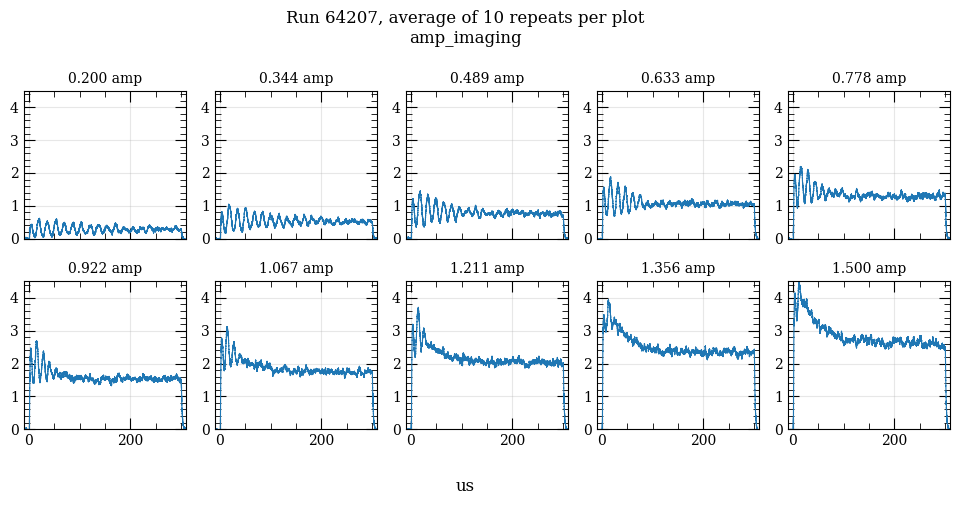

In [14]:
# Example usage:
# averaged_traces is (20, 200000), trace.t[0] is length 200000

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)
labels = [f"{ad.xvars[0][i * ad.params.N_repeats]*xvarmult:.3f} {xvarunit}" for i in range(int(ad.xvardims[0]/ad.p.N_repeats))]
fig, axes = plot_traces_grid(averaged_traces, trace.t[0]*1.e6, labels=labels, ncols=5, decimate=None, figsize=(10,5),
                             suptitle=f'Run {ad.run_info.run_id}, average of {ad.params.N_repeats} repeats per plot\n' +
                             f'{ad.xvarnames[0]}',
                             xlabel='us',
                             ylim=[.0,4.5],xlim=[-10.,310])